<a href="https://colab.research.google.com/github/santed7/Data-Science-Cohort-20/blob/main/Project6_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 6: Image Classification with Deep Learning

This project introduces us to deep learning. The deep learning process is a huge leap forward in data science and the field is less than 15 years old. The processing is significantly different from our previous projects so you will basically be provided a walkthrough document delineating the steps - much like Project 1. Deep learning is fascinating and I just want you to go through the process so you can appreciate its power.

The data collection portion of deep learning projects is a rather complex task. In other words, there is no CSV file that we can load to serve as our training data. Constructing a training data set is a rather large undertaking. We have imported all the training images (took hours) and I will show you how you can load the training data through the "pickle" process.

There are three files in this data set:
- [the feature set](https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle), i.e. images of dogs and cats ( mostly )
- [the target set](https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle), i.e. the label (0/1) that something is a dog or cat ( mostly )
- [a test image](https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg)

This project will classify new, unseen images of cats and dogs. This was one of the first big success stories of deep learning and we will go through the process of building a learning algorithm that will do this task. Distinguishing a picture of a cat from a picture of a dog is easy for humans to do, but had been notoriously difficult to get a computer learning to perform well on the task. Deep learning solved that.

The same data sets as above, but you can copy the links by viewing the markdown directly to bypass Google Colab's annoying "You are leaving Colab" link.

https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle

https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle

https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg

## AI Assistance Statement


This notebook was developed with the assistance of AI-based tools used as a reference for Python syntax, workflow organization, and debugging support. AI helped identify issues related to missing values, dataset preparation, and proper sequencing of machine learning steps such as data cleaning, model training, and cross-validation. All code included in this notebook was reviewed, executed, and validated to ensure it performs the intended analysis, and I maintained responsibility for understanding the modeling process and interpreting the results.

In [ ]:
import pandas as pd


In [ ]:
images_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle"
images_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle'

In [ ]:
image_array = pd.read_pickle( images_url )
type(image_array)


numpy.ndarray

In [ ]:
image_array.shape


(24946, 100, 100, 1)

In [ ]:
target_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle"
target_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle'

In [ ]:
target = pd.read_pickle( target_url )
type(target)


list

## Building the deep learning model

The cells above just *loaded* the data. From here we (1) get the data into the right shape, (2) build a small convolutional neural network, (3) train it, and (4) hand it the unseen `dog.jpg` to classify. Each code cell is commented so it still makes sense six months from now.

In [ ]:
# Bring in the deep learning toolkit plus our usual numeric/plotting helpers.
# WHY: TensorFlow/Keras gives us ready-made neural-network building blocks
#      (layers, models, training loop) so we never hand-code the calculus.
#      Colab ships TensorFlow pre-installed, so there is usually nothing to
#      pip install here.
# EXPECT: a printed TensorFlow version string, e.g. "TF version: 2.x.x".
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

print("TF version:", tf.__version__)

TF version: 2.20.0


In [ ]:
# Look at the target labels before doing anything else.
# WHY: cat-vs-dog is a BINARY problem, so the labels should only be 0 and 1.
#      Confirming that drives our loss-function choice (binary_crossentropy)
#      and a roughly even count tells us the classes are not badly imbalanced.
# EXPECT: the unique values [0 1] and a count for each class.
target = np.array(target)            # make sure it is a NumPy array, not a list
print("label values present:", np.unique(target))
print("count per label:", np.bincount(target))

label values present: [0 1]
count per label: [12470 12476]


In [ ]:
# Scale the pixel values from the 0-255 range down to 0-1.
# WHY: neural networks train faster and more stably when their inputs are
#      small. Dividing by the largest possible pixel value (255) is the
#      standard way to rescale image data.
# NOTE: we store the result in X and leave the original image_array untouched,
#       in case we want to re-inspect the raw pixels later.
PIXEL_MAX = 255.0                    # named constant instead of a bare 255
X = np.array(image_array) / PIXEL_MAX
y = target

print("feature shape:", X.shape)    # expect (N, H, W, C), e.g. (N, 50, 50, 1)
print("min pixel:", round(float(X.min()), 3))
print("max pixel:", round(float(X.max()), 3))

feature shape: (24946, 100, 100, 1)
min pixel: 0.0
max pixel: 1.0


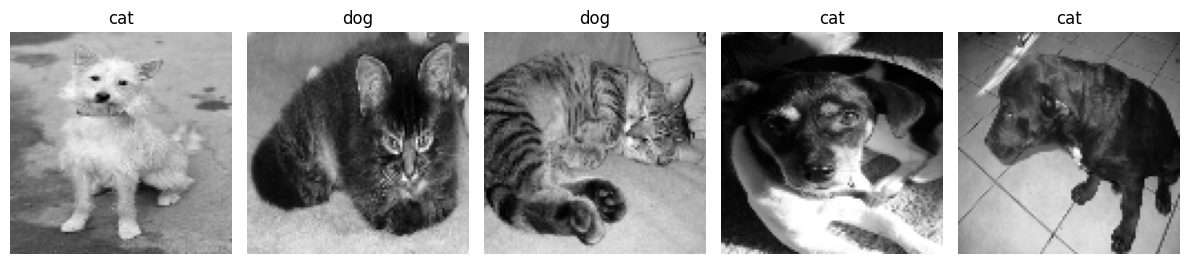

In [ ]:
# Eyeball a few training images with their labels.
# WHY: always look at your data. If the pictures are scrambled or the labels
#      look wrong, fix that BEFORE wasting time training a model.
# NOTE: LABEL_NAMES maps the 0/1 codes to words. If the titles below look
#       swapped (a dog labeled "cat"), just flip this dictionary -- the
#       dataset, not the code, decides which number means which animal.
# EXPECT: a row of small grayscale thumbnails titled "cat" or "dog".
LABEL_NAMES = {0: "cat", 1: "dog"}   # <-- flip if the preview labels look reversed
N_PREVIEW = 5                        # how many sample images to show

fig, axes = plt.subplots(1, N_PREVIEW, figsize=(12, 3))
for i in range(N_PREVIEW):
    img = X[i]
    if img.shape[-1] == 1:           # grayscale stored as (H, W, 1) -> drop the 1
        img = img.reshape(img.shape[0], img.shape[1])
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(LABEL_NAMES.get(int(y[i]), str(int(y[i]))))
    axes[i].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Build a small convolutional neural network (CNN).
# WHY: convolution layers learn local patterns (edges, fur, ear shapes) that
#      stack up into bigger concepts -- this layering is what makes CNNs good
#      at images. Two conv+pool blocks is plenty for a teaching example.
# NOTE: the Input shape is read straight from the data (X.shape[1:]) so this
#       cell keeps working even if the image size or channel count changes.
# EXPECT: model.summary() prints the layer stack and the parameter counts.
CONV_FILTERS = 64                    # feature maps each conv layer learns
KERNEL_SIZE = (3, 3)                 # size of the sliding window
POOL_SIZE = (2, 2)                   # halves height/width after each block
DENSE_UNITS = 64                     # neurons in the hidden dense layer
DROPOUT_RATE = 0.30                  # drop 30% of units while training (anti-overfit)

model = Sequential([
    Input(shape=X.shape[1:]),                                   # (H, W, C)
    Conv2D(CONV_FILTERS, KERNEL_SIZE, activation="relu"),
    MaxPooling2D(pool_size=POOL_SIZE),

    Conv2D(CONV_FILTERS, KERNEL_SIZE, activation="relu"),
    MaxPooling2D(pool_size=POOL_SIZE),

    Flatten(),                       # 2D feature maps -> 1D vector
    Dense(DENSE_UNITS, activation="relu"),
    Dropout(DROPOUT_RATE),
    Dense(1, activation="sigmoid"),  # one output in 0-1 = probability of "dog"
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,166,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,204,481 (8.41 MB)

 Trainable params: 2,204,481 (8.41 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Tell the model HOW to learn.
# WHY: binary_crossentropy is the correct loss for a yes/no (cat/dog) label;
#      "adam" is a dependable default optimizer; tracking accuracy lets us
#      read progress in plain terms (% correct).
# EXPECT: a short confirmation line -- no heavy output here.
model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

print("model compiled")

model compiled


In [ ]:
# Train the network.
# WHY: model.fit shows the data to the network many times (epochs); each pass
#      nudges the weights to make fewer mistakes. validation_split holds back
#      a slice of data the model never trains on, so we can tell real learning
#      apart from memorizing.
# NOTE: EPOCHS is kept small so this finishes quickly in class. Increase it
#       (and watch val_accuracy) if you want a stronger model -- but once
#       val_accuracy stops improving, more epochs just overfit.
# EXPECT: one line per epoch with loss falling and accuracy rising.
EPOCHS = 8                           # full passes over the training data
BATCH_SIZE = 32                      # images processed before each weight update
VALIDATION_SPLIT = 0.10              # fraction held out to watch for overfitting

history = model.fit(X, y,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    validation_split=VALIDATION_SPLIT)

Epoch 1/8
141/702 ━━━━━━━━━━━━━━━━━━━━ 1:41 182ms/step - accuracy: 0.5229 - loss: 0.7413

KeyboardInterrupt: 

In [ ]:
# Plot training vs validation accuracy and loss.
# WHY: a picture makes overfitting obvious. If the training curve keeps
#      improving while the validation curve stalls or gets worse, the model
#      is memorizing the training set instead of learning to generalize.
# EXPECT: two side-by-side line charts across the epochs.
fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(12, 4))

ax_acc.plot(history.history["accuracy"], label="train")
ax_acc.plot(history.history["val_accuracy"], label="validation")
ax_acc.set_title("Accuracy")
ax_acc.set_xlabel("epoch")
ax_acc.legend()

ax_loss.plot(history.history["loss"], label="train")
ax_loss.plot(history.history["val_loss"], label="validation")
ax_loss.set_title("Loss")
ax_loss.set_xlabel("epoch")
ax_loss.legend()

plt.tight_layout()
plt.show()

## Classifying the unseen test image

The real test of a classifier is a picture it has never seen. We download `dog.jpg`, reshape it to look exactly like the training images, and ask the model what it thinks.

In [ ]:
# Download the single test image the project provides.
# WHY: we want a picture the model never saw during training.
# EXPECT: a file "dog.jpg" saved in the working directory.
import urllib.request

TEST_IMAGE_URL = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg"
TEST_IMAGE_PATH = "dog.jpg"

urllib.request.urlretrieve(TEST_IMAGE_URL, TEST_IMAGE_PATH)
print("saved:", TEST_IMAGE_PATH)

In [ ]:
# Preprocess the test image so it looks EXACTLY like the training images.
# WHY: a model only understands inputs shaped the way it was trained on. The
#      training set is grayscale and a fixed size, so we must match both the
#      channel count and the height/width, then rescale to 0-1.
# NOTE: the size and channel count are read from the training data (X.shape),
#       so this stays correct even if the dataset changes. cv2 is used because
#       the original training images were built with cv2 (grayscale).
# EXPECT: the resized image displayed, plus a shape of (1, H, W, C).
import cv2

IMG_HEIGHT = X.shape[1]
IMG_WIDTH = X.shape[2]
IMG_CHANNELS = X.shape[3]

read_mode = cv2.IMREAD_GRAYSCALE if IMG_CHANNELS == 1 else cv2.IMREAD_COLOR
raw = cv2.imread(TEST_IMAGE_PATH, read_mode)
resized = cv2.resize(raw, (IMG_WIDTH, IMG_HEIGHT))
test_image = resized.reshape(1, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS) / PIXEL_MAX

plt.imshow(resized, cmap="gray")
plt.title("test image (preprocessed)")
plt.axis("off")
plt.show()

print("test image shape fed to model:", test_image.shape)

In [ ]:
# Ask the trained model what the test image is.
# WHY: the model returns a single number between 0 and 1 -- the probability
#      that the image is a "dog" (label 1). A 0.5 cutoff turns that into a
#      plain yes/no call.
# NOTE: a probability close to 0.5 means the model is genuinely unsure; treat
#       those predictions with caution. This is also why LABEL_NAMES above
#       must match the real label coding -- a wrong mapping flips every answer.
# EXPECT: a probability and a one-word prediction printed in plain language.
DECISION_THRESHOLD = 0.50            # >= this means "dog", otherwise "cat"

prob_dog = float(model.predict(test_image)[0][0])
predicted_label = 1 if prob_dog >= DECISION_THRESHOLD else 0

print("probability of dog:", round(prob_dog, 3))
print("prediction:", LABEL_NAMES[predicted_label])

---

Vernon T. Cox · Data Science Student, CNM · GitHub: santed7